# 0.Library

In [10]:
# general
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re
import importlib

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_validate
from sklearn.pipeline import Pipeline

# MLFlow
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient

# Paths
import sys
sys.path.append('../') 
from features import data_utils as du
from features import data_pipeline as dp
from features import general_func as gf
import constants_data as cd
from features import model_utils as mu

# Reload
importlib.reload(du)
importlib.reload(dp)
importlib.reload(gf)
importlib.reload(cd)
importlib.reload(mu)

<module 'features.model_utils' from '/home/smira/myproject/detection_AD_with_VR_data/src/notebooks/../features/model_utils.py'>

# 1. Paths and Constants

In [11]:
# Read dataframe
parent_folder = Path("../..") # go 2 folder up= "../.."
df_path = parent_folder / "data" / "produced_csv" / "2.cleaned_features_20_patients.csv"
 
df = pd.read_csv(df_path)

df.head()

,Age,Help_Rating_out_of_5,MoCA_Score,Tutorial_total_reading_time,Tutorial_intensity_reading_time,Tutorial_total_count_hover,Tutorial_total_duration_hover,Tutorial_mean_duration_hover,Tutorial_max_duration_hover,Tutorial_total_count_press,...,Memory_Yaw_std,Memory_Pitch_std,Memory_Roll_std,Memory_Yaw_range,Memory_Roll_range,Memory_dominant_hand_mean_speed,Memory_not_dominant_hand_mean_speed,Memory_dominant_hand_z_range,Memory_not_dominant_hand_y_range,Gender_Male
0,73.0,4,28.0,45.03,0.92,32,20.64,1.03,2.29,8,...,26.23,161.72,177.36,99.05,360.00,0.16,0.03,0.82,0.80,0
1,82.0,1,26.0,338.75,0.99,688,145.79,2.11,20.01,9,...,23.27,161.90,162.61,109.38,359.99,0.06,0.01,0.98,0.75,1
2,62.0,1,27.0,152.90,0.97,61,54.33,1.81,11.62,8,...,30.07,170.64,169.17,248.93,359.98,0.12,0.02,1.05,0.58,1
3,78.0,2,27.0,181.69,0.98,26,91.62,2.78,23.45,9,...,31.96,136.51,170.83,174.64,359.98,0.12,0.02,0.82,0.42,0
4,71.0,2,26.0,190.51,0.98,109,102.68,2.57,21.86,8,...,27.48,169.32,125.66,146.78,359.99,0.11,0.03,0.82,0.64,0


# 2. Data visualization

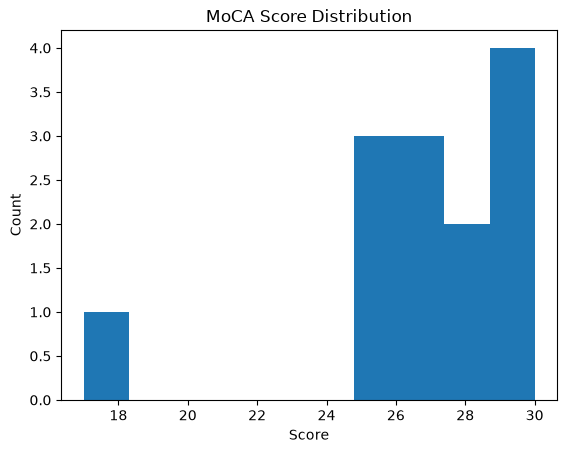

In [12]:
plt.hist(df['MoCA_Score'], bins=10)
plt.title("MoCA Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

Fill MoCA by 26(int) for all 20 young patient...
Fill Nan by median for real patient...
No more Nan values in MoCA.
MoCA column is dropped and Target column is created successfully.


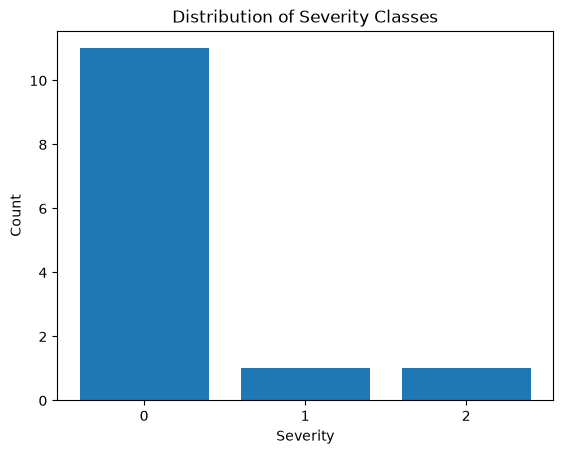

In [13]:
df_classification = dp.create_target_column(df)

counts = df_classification["Target"].value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)

plt.xlabel("Severity")
plt.ylabel("Count")
plt.title("Distribution of Severity Classes")
plt.show()

# 3. Data Splitting

In [14]:
y = df['MoCA_Score']
df = df.drop(columns=['MoCA_Score'])
X = df

# 4. Set one : Feature selection + Train + log to MLFlow

In [ ]:
# experiment list
experiments_list = cd.all_experiments_sol_1
loo = LeaveOneOut()

for exp_name, models_list, k_value in experiments_list:
    
    print(f"================ Experiment: {exp_name} with k={k_value} ================")
    mlflow.set_experiment(f"MoCA_Regression_feaute_selection_{exp_name}_{k_value}")

    for model_name, model_fn in models_list:
        print(f"======== Run: {exp_name}_{model_name} ========")
        with mlflow.start_run(run_name=f"{exp_name}_{model_name}"):

            pipe = mu.make_model_pipeline(
                mu.make_feature_pipeline(exp_name, k_value),
                model_fn()
            )

            scores = cross_validate(
                pipe,
                X,
                y,
                cv=loo,
                scoring={
                    "mae": "neg_mean_absolute_error",
                    "mse": "neg_mean_squared_error",
                    "rmse": "neg_root_mean_squared_error"
                },
                return_train_score=True
            )

            # compute metrics of test set
            mae_test  = -scores["test_mae"].mean()
            mse_test  = -scores["test_mse"].mean()
            rmse_test = -scores["test_rmse"].mean()

            # compute metrics of train set
            mae_train  = -scores["train_mae"].mean()
            mse_train  = -scores["train_mse"].mean()
            rmse_train = -scores["train_rmse"].mean()

            # compute gap (overfitting)
            gap = mse_test - mse_train

            # print
            print(f"Model: {model_name}")
            print(f"MSE of test: {mse_test:.3f}")
            print(f"MSE of train: {mse_train:.3f}")
            print(f"Gap: {gap:.3f}")

            # MLflow logging
            mlflow.log_param("experiment", exp_name)
            mlflow.log_param("model", model_name)

            mlflow.log_metric("mae_test", mae_test)
            mlflow.log_metric("mse_test", mse_test)
            mlflow.log_metric("rmse_test", rmse_test)

            mlflow.log_metric("mae_train", mae_train)
            mlflow.log_metric("mse_train", mse_train)
            mlflow.log_metric("rmse_train", rmse_train)

            mlflow.log_metric("gap", gap)

            # log model
            mlflow.sklearn.log_model(pipe, name="model", skops_trusted_types=["xgboost.sklearn.XGBRegressor", "sklearn.feature_selection._univariate_selection.f_regression"])


======== Experiment: all_features with k=0 ===========
================ Run: all_features_LinearRegression =================
Model: LinearRegression
MSE of test: 10.036
MSE of train: 0.000
Gap: 10.036
================ Run: all_features_Ridge =================
Model: Ridge
MSE of test: 10.020
MSE of train: 0.000
Gap: 10.019
================ Run: all_features_RandomForest =================
Model: RandomForest
MSE of test: 10.366
MSE of train: 1.000
Gap: 9.367
================ Run: all_features_XGBRegressor =================
Model: XGBRegressor
MSE of test: 25.601
MSE of train: 0.000
Gap: 25.601
================ Run: all_features_SVR =================
Model: SVR
MSE of test: 11.016
MSE of train: 7.203
Gap: 3.813
================ Run: all_features_Lasso =================
Model: Lasso
MSE of test: 12.317
MSE of train: 1.976
Gap: 10.341
======== Experiment: SelectKBest with k=50 ===========
================ Run: SelectKBest_LinearRegression =================
Model: LinearRegression
MSE of te

# 5. Set two : Data augmentation + Train + log to MLFlow

In [16]:
cd.all_experiments_sol_1, cd.all_experiments_sol_2

([('all_features',
   [('LinearRegression', sklearn.linear_model._base.LinearRegression),
    ('Ridge', sklearn.linear_model._ridge.Ridge),
    ('RandomForest', <function constants_data.<lambda>()>),
    ('XGBRegressor', <function constants_data.<lambda>()>),
    ('SVR', sklearn.svm._classes.SVR),
    ('Lasso', sklearn.linear_model._coordinate_descent.Lasso)],
   0),
  ('SelectKBest',
   [('LinearRegression', sklearn.linear_model._base.LinearRegression),
    ('Ridge', sklearn.linear_model._ridge.Ridge),
    ('RandomForest', <function constants_data.<lambda>()>),
    ('XGBRegressor', <function constants_data.<lambda>()>),
    ('SVR', sklearn.svm._classes.SVR),
    ('Lasso', sklearn.linear_model._coordinate_descent.Lasso)],
   50),
  ('SelectKBest',
   [('LinearRegression', sklearn.linear_model._base.LinearRegression),
    ('Ridge', sklearn.linear_model._ridge.Ridge),
    ('RandomForest', <function constants_data.<lambda>()>),
    ('XGBRegressor', <function constants_data.<lambda>()>),
 

In [17]:
# experiment list
experiments_list = cd.all_experiments_sol_2

for exp_name, models_list in experiments_list:
    
    print(f"======== Experiment: {exp_name} ===========")
    mlflow.set_experiment(f"MoCA_Regression_data_augmentation_{exp_name}")

    for model in models_list:
        print(f"================ Run: {exp_name}_{model.__name__} =================")
        with mlflow.start_run(run_name=f"{exp_name}_{model.__name__}"):

            pipe = mu.make_model_pipeline(
                mu.make_feature_pipeline(exp_name, k_value),
                model()
            )

            scores = cross_validate(
                pipe,
                X,
                y,
                cv=5,
                scoring={
                    "r2": "r2",
                    "mae": "neg_mean_absolute_error",
                    "mse": "neg_mean_squared_error",
                    "rmse": "neg_root_mean_squared_error"
                },
                return_train_score=True
            )

            # compute metrics of test set
            r2_test   = scores["test_r2"].mean()
            mae_test  = -scores["test_mae"].mean()
            mse_test  = -scores["test_mse"].mean()
            rmse_test = -scores["test_rmse"].mean()

            # compute metrics of train set
            r2_train   = scores["train_r2"].mean()
            mae_train  = -scores["train_mae"].mean()
            mse_train  = -scores["train_mse"].mean()
            rmse_train = -scores["train_rmse"].mean()

            # print
            print(f"Model: {model.__name__}")
            print(f"R² of test: {mse_test:.3f}")

            # MLflow logging
            mlflow.log_param("experiment", exp_name)
            mlflow.log_param("model", model.__name__)

            mlflow.log_metric("r2_test", r2_test)
            mlflow.log_metric("mae_test", mae_test)
            mlflow.log_metric("mse_test", mse_test)
            mlflow.log_metric("rmse_test", rmse_test)

            mlflow.log_metric("r2_test", r2_train)
            mlflow.log_metric("mae_test", mae_train)
            mlflow.log_metric("mse_test", mse_train)
            mlflow.log_metric("rmse_test", rmse_train)

            mlflow.log_metric("gap", abs(mse_test - mse_train))

            # log model
            mlflow.sklearn.log_model(pipe, name="model", skops_trusted_types=["xgboost.sklearn.XGBRegressor", "sklearn.feature_selection._univariate_selection.f_regression"])


======== Experiment: zero_aug ===========


AttributeError: 'tuple' object has no attribute '__name__'

## 5.0 Split train/test and Scale

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [ ]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5.1 Gaussian noise

In [ ]:
X_train_aug , y_train_aug = du.guassian_noise_pipeline(loc=0, scale=1, 
                                                       X_train_scaled= X_train_scaled, y_train= y_train, 
                                                       original_cols= X_train.columns)

In [ ]:
X_train_aug.shape , y_train_aug.shape

((26, 119), (26,))

## 5.2 SMOTER

In [ ]:
import numpy as np

Q1 = np.quantile(y_train, 0.25)
Q2 = np.quantile(y_train, 0.50)  # median
Q3 = np.quantile(y_train, 0.75)

print("Q1:", Q1)
print("Q2:", Q2)
print("Q3:", Q3)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("lower_fence:",lower_fence)
print("upper_fence:", upper_fence)

Q1: 26.0
Q2: 27.0
Q3: 28.0
lower_fence: 23.0
upper_fence: 31.0


In [ ]:
y_train

3     27.0
18    27.0
16    27.0
13    17.0
2     26.0
9     25.0
19    29.0
4     27.0
12    27.0
7     29.0
10    28.0
14    30.0
6     26.0
Name: MoCA_Score, dtype: float64

In [ ]:
relevance_series = y_train.apply(
    lambda v: "rare" if (v < lower_fence or v > upper_fence) else "normal"
)

In [ ]:
relevance_series

3     normal
18    normal
16    normal
13      rare
2     normal
9     normal
19    normal
4     normal
12    normal
7     normal
10    normal
14    normal
6     normal
Name: MoCA_Score, dtype: object

In [ ]:
rare_indices = [
    idx for idx, val in relevance_series.items()
    if val == "rare"
]
rare_indices

[13]

In [ ]:
X_rare = X_train.loc[rare_indices]
y_rare = y_train.loc[rare_indices]

In [ ]:
X_rare

,Age,Help_Rating_out_of_5,Tutorial_total_reading_time,Tutorial_max_reading_time,Tutorial_intensity_reading_time,Tutorial_total_duration_hover,Tutorial_mean_duration_hover,Tutorial_max_duration_hover,Tutorial_std_duration_hover,Tutorial_total_count_press,...,Memory_Yaw_std,Memory_Pitch_std,Memory_Roll_std,Memory_Yaw_range,Memory_dominant_hand_mean_speed,Memory_not_dominant_hand_mean_speed,Memory_dominant_hand_z_range,Memory_not_dominant_hand_y_range,Gender_Male,dominant_hand_Right
13,79.0,4,534.07,206.77,0.99,154.15,2.96,40.76,7.92,9,...,31.27,170.65,78.32,289.87,0.09,0.01,1.26,0.79,1,0


In [ ]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=3)
knn.fit(X_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'eu...an'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


In [ ]:
X_rare

NameError: name 'X_rare' is not defined

In [ ]:
def relevance_func(value: float):
    pass

# 6. Set three : Best of Data augmentation and Feature selection + Train + log to MLFlow